# Исследование датасета кредитного скоринга ООО «Комус»
### Exploratory Data Analysis (EDA)



## О работе

В данном ноутбуке проводится первичный исследовательский анализ (Exploratory Data Analysis, EDA) датасета, предоставленного для решения задачи кредитного скоринга.

Цель исследования — познакомиться с данными, оценить их качество, изучить структуру признаков и выявить особенности, которые могут повлиять на дальнейшее построение моделей машинного обучения.

## Что будет сделано

В ходе работы последовательно выполним:

- загрузку и первичный обзор датасета;
- исследование целевой переменной;
- анализ структуры признаков;
- проверку качества данных;
- изучение статистических характеристик числовых признаков;
- визуальный анализ распределений;
- сравнение распределений признаков для организаций с дефолтом и без него;
- анализ корреляции признаков;
- формулировку итоговых выводов.

## Что не входит в исследование

В данном ноутбуке не рассматриваются построение, обучение и сравнение моделей машинного обучения. Основная задача — подготовить данные к следующему этапу работы и получить полное представление об их структуре и качестве.

# Оглавление

1. [Загрузка данных](#1.-Загрузка-данных)
2. [Исследование целевой переменной](#2.-Исследование-целевой-переменной)
3. [Исследование структуры признаков](#3.-Исследование-структуры-признаков)
4. [Оценка качества данных](#4.-Оценка-качества-данных)
5. [Первичный анализ числовых признаков](#5.-Первичный-анализ-числовых-признаков)
6. [Анализ распределения признаков](#6.-Анализ-распределения-признаков)
7. [Сравнение распределений признаков в зависимости от факта дефолта](#7.-Сравнение-распределений-признаков-в-зависимости-от-факта-дефолта)
8. [Анализ корреляции признаков](#8.-Анализ-корреляции-признаков)
9. [Итоговое заключение](#9.-Итоговое-заключение)

# 1. Загрузка данных

## 🎯 Цель

Первым этапом любого исследования является загрузка данных и проверка их корректного чтения. До начала анализа необходимо убедиться, что датасет успешно загружен, имеет ожидаемую структуру и готов к дальнейшей обработке.



## 📌 Почему этот этап выполняется сейчас?

Любой последующий анализ полностью зависит от качества загрузки данных. Если на этом этапе возникнут ошибки чтения файла, некорректно определятся типы данных или часть информации будет потеряна, результаты исследования окажутся недостоверными.

Поэтому перед изучением признаков необходимо проверить общую структуру набора данных.



## 🛠️ Решение

На данном этапе выполняется:

- загрузка предоставленного заказчиком датасета;
- определение количества наблюдений и признаков;
- просмотр первых строк таблицы;
- проверка структуры датасета и типов данных.



## 📈 Что ожидаем увидеть?

В результате выполнения данного этапа необходимо убедиться, что:

- файл успешно считан;
- количество строк и столбцов соответствует ожидаемому;
- все признаки загружены корректно;
- типы данных определены без критических ошибок.



## ✅ Почему выбран именно этот метод?

Первичный анализ структуры датасета является стандартным этапом исследования данных (Exploratory Data Analysis, EDA). Он позволяет быстро оценить качество загрузки данных и обнаружить возможные проблемы ещё до проведения более глубокого анализа.



In [ ]:
!pip -q install pyxlsb

In [ ]:
import pandas as pd

FILE = "/content/sample_data/Data_final.xlsb"

df = pd.read_excel(
    FILE,
    engine="pyxlsb"
)

print("Файл успешно загружен.")

Файл успешно загружен.


In [ ]:
print(f"Количество строк: {df.shape[0]:,}")
print(f"Количество столбцов: {df.shape[1]}")

Количество строк: 362,018
Количество столбцов: 51


In [ ]:
# Просмотр первых строк датасета
df.head()

,INN,DefMark,Q_A1_norm,Q_A2_norm,Q_A3_norm,Q_A4_norm,Q_A5_norm,Q_A6_norm,Q_A7_norm,Q_B1_norm,...,E3_norm,F1_norm,F2_norm,F3_norm,F4_norm,G1_norm,G2_norm,G3_norm,G4_norm,G5_norm
0,1215230006,0,2.333,52.5418,9.4494,38.3585,42.4527,-30.7698,30.8994,34.6347,...,-2.3386,-41.5491,-14.6783,20.7119,-7.7164,36.6006,-31.8809,-35.9536,-34.6305,51.0379
1,1215230165,0,2.333,52.5418,9.4494,-9.4678,42.4527,76.5957,-131.2192,7.2799,...,-16.4782,2.6523,-14.6783,-0.0980,-7.7164,26.2257,132.4186,106.8055,151.1952,-131.8824
2,1215230278,0,2.333,52.5418,9.4494,60.8612,24.7409,-30.7698,-47.3796,7.2799,...,-14.3848,-53.2628,-26.3341,40.4643,-7.1363,-24.2547,-18.5226,-33.6243,-32.5097,17.2635
3,1215232067,0,2.333,52.5418,9.4494,38.3585,24.7409,-30.7698,30.8994,7.2799,...,-16.4782,2.6523,-14.6783,20.7119,-7.7164,14.0589,-33.1762,-27.9957,-27.6181,16.0999
4,1215232733,0,2.333,52.5418,9.4494,38.3585,24.7409,-30.7698,46.9948,34.6347,...,11.9397,2.6523,-14.6783,-18.6647,-7.7164,-4.8419,13.7945,115.9358,57.2188,18.9675


In [ ]:
# Получение описательной статистики по числовым признакам
df.describe().T

,count,mean,std,min,25%,50%,75%,max
INN,362018.0,6.601175e+09,2.048091e+09,1.000002e+08,5.262338e+09,7.707418e+09,7.736290e+09,9.901037e+09
DefMark,362018.0,9.673276e-02,2.955939e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
Q_A1_norm,362018.0,1.353478e-02,5.001070e+01,-9.009711e+02,-2.647070e+01,-2.298800e+01,3.002190e+01,2.826151e+03
Q_A2_norm,362018.0,-7.603851e-02,4.960965e+01,-1.636760e+01,-1.636760e+01,-1.636760e+01,-1.636760e+01,8.770959e+02
Q_A3_norm,362018.0,5.148816e-03,4.999173e+01,-7.317676e+02,9.449400e+00,9.449400e+00,9.449400e+00,8.094377e+02
Q_A4_norm,362018.0,-3.676141e-03,5.000122e+01,-7.641037e+02,-9.912800e+00,-9.467800e+00,3.835850e+01,1.150717e+02
Q_A5_norm,362018.0,4.801189e-04,5.000211e+01,-1.306391e+02,-8.688300e+00,2.474090e+01,2.474090e+01,4.375480e+01
Q_A6_norm,362018.0,-3.393981e-03,4.999773e+01,-3.076980e+01,-3.076980e+01,-3.076980e+01,7.659570e+01,9.385810e+01
Q_A7_norm,362018.0,4.147705e-04,4.999736e+01,-1.312192e+02,-4.737960e+01,3.089940e+01,3.089940e+01,4.699480e+01
Q_B1_norm,362018.0,6.058060e-03,4.999671e+01,-1.851505e+02,-1.306390e+01,7.279900e+00,3.463470e+01,3.463470e+01



## 📊 Результаты

Предоставленный датасет содержит **362 018 наблюдений** и **51 признак**, включая идентификатор организации (`INN`) и целевую переменную (`DefMark`).

Структура данных успешно считана, все признаки доступны для дальнейшего исследования.


## 🔎 Интерпретация

Объём выборки является достаточно большим для решения задачи кредитного скоринга и обеспечивает хорошую статистическую основу для анализа.

При количестве около пятидесяти признаков отсутствуют ограничения на применение современных алгоритмов машинного обучения для табличных данных. В дальнейшем могут быть использованы как линейные модели, так и методы градиентного бустинга (например, CatBoost, XGBoost и LightGBM).


## 📝 Выводы

Датасет успешно загружен и готов к дальнейшему исследованию. Его объём и структура позволяют перейти к следующему этапу — изучению целевой переменной и последующему анализу качества данных и признакового пространства.

# 2. Исследование целевой переменной

## 🎯 Цель

Перед построением модели необходимо изучить целевую переменную(таргет) `DefMark` и понять, как распределены классы в датасете.

## 📌 Почему этот этап выполняется сейчас?

Модель будет обучаться предсказывать именно значение целевой переменной. Поэтому важно заранее понять, сколько в данных организаций с дефолтом и без него.

Если один класс встречается значительно реже другого, это может повлиять на обучение модели и на выбор метрик для оценки её качества.

## 🛠️ Решение

На данном этапе определим:

- количество организаций каждого класса;
- процентное соотношение классов;
- степень дисбаланса целевой переменной.

## 📈 Что ожидаем увидеть?

Ожидаем определить, является ли датасет сбалансированным или один из классов встречается значительно реже другого.

## ✅ Почему выбран именно этот метод?

Подсчёт количества объектов каждого класса — самый простой и информативный способ оценить баланс целевой переменной перед началом моделирования.

In [ ]:
# Подсчёт количества организаций каждого класса

target_counts = df["DefMark"].value_counts().sort_index()

target_counts

,count
DefMark,
0,326999
1,35019


In [ ]:
# Расчёт процентного соотношения классов

target_percent = (
    df["DefMark"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_percent

,proportion
DefMark,
0,90.326724
1,9.673276


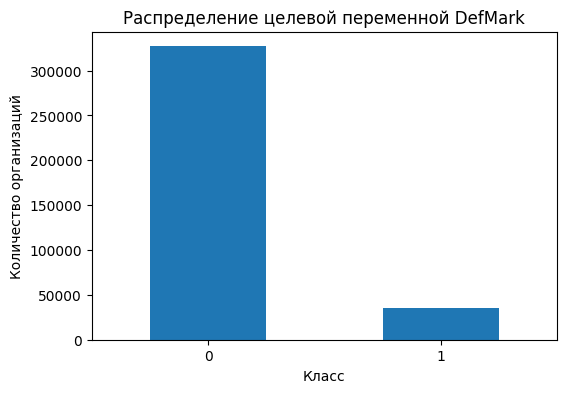

In [ ]:
# @title
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

target_counts.plot(kind="bar")

plt.title("Распределение целевой переменной DefMark")
plt.xlabel("Класс")
plt.ylabel("Количество организаций")

plt.xticks(rotation=0)

plt.show()

In [ ]:
# Вывод количества организаций и доли дефолтов

print(f"Недефолтные организации : {target_counts[0]:,}")
print(f"Дефолтные организации   : {target_counts[1]:,}")

print()

print(f"Доля дефолтов: {target_percent[1]:.2f}%")

Недефолтные организации : 326,999
Дефолтные организации   : 35,019

Доля дефолтов: 9.67%


## 📊 Результаты

Анализ показал, что датасет содержит **326 999 недефолтных организаций (90,33%)** и **35 019 дефолтных организаций (9,67%)**.

## 🔎 Интерпретация

Большинство организаций в выборке являются финансово устойчивыми, тогда как случаи дефолта встречаются значительно реже. Такое распределение характерно для задач кредитного скоринга и считается умеренным дисбалансом классов.

При построении моделей эту особенность необходимо учитывать. Для корректной оценки качества рекомендуется использовать стратифицированное разделение данных, а также метрики, устойчивые к дисбалансу классов, например ROC-AUC и коэффициент Gini.

## 📝 Выводы

Целевая переменная имеет умеренный дисбаланс классов, который соответствует реальным данным кредитного скоринга и не является критической проблемой. Этот фактор будет учитываться на следующих этапах при построении и оценке моделей.

# 3. Исследование структуры признаков

## 🎯 Цель

После знакомства с целевой переменной необходимо изучить структуру самого датасета: определить типы данных, выделить служебные поля и понять, из каких признаков будет обучаться модель.

## 📌 Почему этот этап выполняется сейчас?

Перед дальнейшим анализом важно разобраться, какие данные содержатся в датасете и требуют ли они предварительной обработки.

На этом этапе мы определим, какие столбцы являются признаками, какой столбец содержит целевую переменную, а какой используется только для идентификации организаций.

## 🛠️ Решение

Выполним:

- анализ типов данных;
- просмотр списка всех признаков;
- выделение идентификатора и целевой переменной;
- предварительную группировку признаков по их названиям.

## 📈 Что ожидаем увидеть?

Ожидаем убедиться, что все признаки имеют корректный тип данных и могут использоваться при построении моделей без дополнительного преобразования.

Также интересно проверить, имеют ли названия признаков какую-либо логическую структуру.

## ✅ Почему выбран именно этот метод?

Изучение структуры признаков позволяет заранее понять состав датасета и выявить особенности, которые могут повлиять на дальнейший анализ и подготовку данных.

In [ ]:
# Просмотр типов данных всех столбцов

df.dtypes

,0
INN,int64
DefMark,int64
Q_A1_norm,float64
Q_A2_norm,float64
Q_A3_norm,float64
Q_A4_norm,float64
Q_A5_norm,float64
Q_A6_norm,float64
Q_A7_norm,float64
Q_B1_norm,float64


In [ ]:
# Подсчёт количества столбцов каждого типа данных

df.dtypes.value_counts()

,count
float64,49
int64,2


In [ ]:
# Вывод списка всех признаков датасета

for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

 1. INN
 2. DefMark
 3. Q_A1_norm
 4. Q_A2_norm
 5. Q_A3_norm
 6. Q_A4_norm
 7. Q_A5_norm
 8. Q_A6_norm
 9. Q_A7_norm
10. Q_B1_norm
11. Q_B2_norm
12. Q_B3_norm
13. Q_B4_norm
14. Q_B5_norm
15. Q_C1_norm
16. Q_D1_norm
17. Q_D2_norm
18. Q_D3_norm
19. Q_D4_norm
20. Q_D5_norm
21. Q_D6_norm
22. A1_norm
23. A2_norm
24. A3_norm
25. A4_norm
26. A5_norm
27. A6_norm
28. B1_norm
29. B2_norm
30. B3_norm
31. C1_norm
32. C2_norm
33. C3_norm
34. C4_norm
35. D1_norm
36. D2_norm
37. D3_norm
38. D4_norm
39. D5_norm
40. E1_norm
41. E2_norm
42. E3_norm
43. F1_norm
44. F2_norm
45. F3_norm
46. F4_norm
47. G1_norm
48. G2_norm
49. G3_norm
50. G4_norm
51. G5_norm


In [ ]:
# Выделение идентификатора, целевой переменной и списка признаков(логическое деление)

target = "DefMark"
id_column = "INN"

features = [col for col in df.columns if col not in [target, id_column]]

print(f"ID: {id_column}")
print(f"Целевая переменная: {target}")
print(f"Количество признаков: {len(features)}")

ID: INN
Целевая переменная: DefMark
Количество признаков: 49


In [ ]:
# Предварительная группировка признаков по их названиям

from collections import Counter

groups = []

for col in features:
    if col.startswith("Q_"):
        groups.append("Q")
    else:
        groups.append(col[0])

group_counts = Counter(groups)

print("Группы признаков:\n")

for group in sorted(group_counts):
    print(f"Группа {group}: {group_counts[group]} признаков")

Группы признаков:

Группа A: 6 признаков
Группа B: 3 признаков
Группа C: 4 признаков
Группа D: 5 признаков
Группа E: 3 признаков
Группа F: 4 признаков
Группа G: 5 признаков
Группа Q: 19 признаков


## 📊 Результаты

Анализ структуры датасета показал, что он содержит **49 числовых признаков** типа `float64`, а также два служебных поля: идентификатор организации (`INN`) и целевую переменную (`DefMark`).

Все признаки представлены в числовом формате.

## 🔎 Интерпретация

Поскольку все признаки уже имеют числовой тип, дополнительное кодирование категориальных данных не требуется. Это упрощает дальнейшую подготовку данных и позволяет сразу перейти к их анализу.

Кроме того, названия признаков образуют несколько логических групп (`Q`, `A`, `B`, `C`, `D`, `E`, `F`, `G`). Это позволяет предположить, что признаки были сформированы по определённой системе. Однако для точной интерпретации каждой группы потребуется документация или описание датасета от заказчика.

## 📝 Выводы

Структура датасета хорошо организована и не вызывает замечаний. Все признаки готовы к дальнейшему исследованию, а их группировка может оказаться полезной при анализе результатов и интерпретации моделей.

# 4. Оценка качества данных

## 🎯 Цель

Перед тем как переходить к анализу признаков и построению моделей, необходимо убедиться, что данные не содержат очевидных ошибок.

## 📌 Почему этот этап выполняется сейчас?

Даже большой и хорошо подготовленный датасет может содержать пропущенные значения, дубликаты или признаки, которые не несут полезной информации. Такие проблемы могут повлиять на результаты анализа и качество будущих моделей.

Поэтому сначала проверим, насколько данные готовы к дальнейшей работе.

## 🛠️ Решение

На данном этапе выполним:

- проверку пропущенных значений;
- поиск полных дубликатов;
- поиск признаков с постоянными значениями;
- проверку соответствия между количеством строк и количеством уникальных организаций.

## 📈 Что ожидаем увидеть?

Ожидаем убедиться, что датасет не требует дополнительной очистки и может использоваться для дальнейшего анализа без предварительной обработки.

## ✅ Почему выбран именно этот метод?

Эти проверки входят в стандартный набор процедур первичного анализа данных (EDA) и позволяют быстро выявить наиболее распространённые проблемы качества данных.

In [ ]:
# Проверка пропущенных значений в каждом столбце

missing = df.isnull().sum()

# Оставляем только признаки, в которых есть пропуски
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Количество признаков с пропусками: {len(missing)}")

missing

Количество признаков с пропусками: 0


,0


In [ ]:
# Поиск полных дубликатов

duplicates = df.duplicated().sum()

print(f"Количество полных дубликатов: {duplicates}")

Количество полных дубликатов: 0


In [ ]:
# Поиск признаков, содержащих только одно уникальное значение

constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print(f"Количество константных признаков: {len(constant_columns)}")

constant_columns

Количество константных признаков: 0


[]

In [ ]:
# Проверка, что каждой организации соответствует одна запись

print(f"Всего строк: {len(df):,}")
print(f"Уникальных INN: {df['INN'].nunique():,}")

Всего строк: 362,018
Уникальных INN: 362,018


## 📊 Результаты

Проверка показала, что датасет не содержит пропущенных значений, полных дубликатов и признаков с постоянными значениями.

Также установлено, что каждой строке соответствует уникальная организация, то есть повторяющихся записей по идентификатору `INN` нет.

## 🔎 Интерпретация

Полученные результаты говорят о высоком качестве подготовки данных. Все основные проверки были успешно пройдены, поэтому дополнительная очистка датасета на данном этапе не требуется.

Это позволяет сосредоточиться на исследовании признаков, не опасаясь, что результаты анализа будут искажены проблемами качества данных.

## 📝 Выводы

Датасет полностью готов к дальнейшему исследованию. Проверка качества данных не выявила проблем, которые могли бы повлиять на анализ или последующее построение моделей машинного обучения.


# 5. Первичный анализ числовых признаков

## 🎯 Цель

После проверки качества данных изучим основные статистические характеристики числовых признаков. Это поможет понять, как распределены значения и насколько признаки отличаются друг от друга.

## 📌 Почему этот этап выполняется сейчас?

Перед построением графиков полезно сначала посмотреть на числовые характеристики признаков. Это позволяет быстро оценить диапазоны значений, разброс данных и заметить возможные особенности распределений.

## 🛠️ Решение

Для каждого числового признака рассчитаем:

- минимальное и максимальное значения;
- среднее значение;
- стандартное отклонение;
- медиану и квартили.

## 📈 Что ожидаем увидеть?

Ожидаем получить общее представление о распределении признаков и определить, отличаются ли они по масштабу и вариативности.

## ✅ Почему выбран именно этот метод?

Описательная статистика — один из первых этапов EDA. Она позволяет быстро оценить свойства признаков ещё до их визуального анализа.

In [ ]:
# Расчёт основных статистических характеристик признаков

stats = df.describe().T

stats

,count,mean,std,min,25%,50%,75%,max
INN,362018.0,6.601175e+09,2.048091e+09,1.000002e+08,5.262338e+09,7.707418e+09,7.736290e+09,9.901037e+09
DefMark,362018.0,9.673276e-02,2.955939e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
Q_A1_norm,362018.0,1.353478e-02,5.001070e+01,-9.009711e+02,-2.647070e+01,-2.298800e+01,3.002190e+01,2.826151e+03
Q_A2_norm,362018.0,-7.603851e-02,4.960965e+01,-1.636760e+01,-1.636760e+01,-1.636760e+01,-1.636760e+01,8.770959e+02
Q_A3_norm,362018.0,5.148816e-03,4.999173e+01,-7.317676e+02,9.449400e+00,9.449400e+00,9.449400e+00,8.094377e+02
Q_A4_norm,362018.0,-3.676141e-03,5.000122e+01,-7.641037e+02,-9.912800e+00,-9.467800e+00,3.835850e+01,1.150717e+02
Q_A5_norm,362018.0,4.801189e-04,5.000211e+01,-1.306391e+02,-8.688300e+00,2.474090e+01,2.474090e+01,4.375480e+01
Q_A6_norm,362018.0,-3.393981e-03,4.999773e+01,-3.076980e+01,-3.076980e+01,-3.076980e+01,7.659570e+01,9.385810e+01
Q_A7_norm,362018.0,4.147705e-04,4.999736e+01,-1.312192e+02,-4.737960e+01,3.089940e+01,3.089940e+01,4.699480e+01
Q_B1_norm,362018.0,6.058060e-03,4.999671e+01,-1.851505e+02,-1.306390e+01,7.279900e+00,3.463470e+01,3.463470e+01


In [ ]:
# Просмотр минимальных и максимальных значений признаков

stats[["min", "max"]]

,min,max
INN,1.000002e+08,9.901037e+09
DefMark,0.000000e+00,1.000000e+00
Q_A1_norm,-9.009711e+02,2.826151e+03
Q_A2_norm,-1.636760e+01,8.770959e+02
Q_A3_norm,-7.317676e+02,8.094377e+02
Q_A4_norm,-7.641037e+02,1.150717e+02
Q_A5_norm,-1.306391e+02,4.375480e+01
Q_A6_norm,-3.076980e+01,9.385810e+01
Q_A7_norm,-1.312192e+02,4.699480e+01
Q_B1_norm,-1.851505e+02,3.463470e+01


In [ ]:
# Анализ средних значений и стандартного отклонения

stats[["mean", "std"]]

,mean,std
INN,6.601175e+09,2.048091e+09
DefMark,9.673276e-02,2.955939e-01
Q_A1_norm,1.353478e-02,5.001070e+01
Q_A2_norm,-7.603851e-02,4.960965e+01
Q_A3_norm,5.148816e-03,4.999173e+01
Q_A4_norm,-3.676141e-03,5.000122e+01
Q_A5_norm,4.801189e-04,5.000211e+01
Q_A6_norm,-3.393981e-03,4.999773e+01
Q_A7_norm,4.147705e-04,4.999736e+01
Q_B1_norm,6.058060e-03,4.999671e+01


In [ ]:
# Анализ медианы и квартилей

stats[["25%", "50%", "75%"]]

,25%,50%,75%
INN,5.262338e+09,7.707418e+09,7.736290e+09
DefMark,0.000000e+00,0.000000e+00,0.000000e+00
Q_A1_norm,-2.647070e+01,-2.298800e+01,3.002190e+01
Q_A2_norm,-1.636760e+01,-1.636760e+01,-1.636760e+01
Q_A3_norm,9.449400e+00,9.449400e+00,9.449400e+00
Q_A4_norm,-9.912800e+00,-9.467800e+00,3.835850e+01
Q_A5_norm,-8.688300e+00,2.474090e+01,2.474090e+01
Q_A6_norm,-3.076980e+01,-3.076980e+01,7.659570e+01
Q_A7_norm,-4.737960e+01,3.089940e+01,3.089940e+01
Q_B1_norm,-1.306390e+01,7.279900e+00,3.463470e+01


## 📊 Результаты

Для каждого числового признака были рассчитаны основные статистические характеристики: минимальное и максимальное значения, среднее, стандартное отклонение, медиана и квартили.

Анализ показал, что признаки имеют различные диапазоны значений и отличаются по степени изменчивости. Для некоторых признаков первый, второй и третий квартили совпадают, что говорит о высокой концентрации наблюдений в определённом диапазоне значений.

## 🔎 Интерпретация

Различия в статистических характеристиках показывают, что финансовые показатели имеют неодинаковую вариативность. Одни признаки изменяются в широких пределах, тогда как другие принимают близкие значения для большинства организаций.

Эти особенности важно учитывать при дальнейшем анализе распределений и выборе методов машинного обучения.

## 📝 Выводы

Первичный статистический анализ позволил получить общее представление о числовых признаках и подтвердил, что они обладают различной структурой распределения. На следующем этапе перейдём к их визуальному анализу, чтобы более детально изучить форму распределений и возможные особенности данных.

# 6. Анализ распределения признаков

## 🎯 Цель

После изучения основных статистических характеристик посмотрим, как значения признаков распределены на практике. Это поможет лучше понять структуру данных и выявить особенности, которые не всегда заметны по числовым показателям.

## 📌 Почему этот этап выполняется сейчас?

Среднее значение, медиана и квартили дают лишь общее представление о данных. Однако они не показывают форму распределения, наличие асимметрии, выбросов или концентрации значений.

Поэтому следующим шагом выполним визуальный анализ признаков.

## 🛠️ Решение

Построим гистограммы для нескольких признаков и оценим:

- форму распределения;
- наличие асимметрии;
- возможные выбросы;
- концентрацию наблюдений в отдельных диапазонах.

## 📈 Что ожидаем увидеть?

Ожидаем определить, насколько отличаются распределения признаков и есть ли среди них особенности, которые могут оказаться полезными при дальнейшем анализе.

## ✅ Почему выбран именно этот метод?

Гистограмма — один из самых простых и наглядных способов изучить распределение числового признака. Она позволяет быстро увидеть особенности, которые сложно заметить по таблице статистических характеристик.

In [ ]:
# Импорт библиотеки для построения графиков

import matplotlib.pyplot as plt

Для примера рассмотрим несколько признаков из разных групп. Такой подход позволяет показать основные типы распределений, не перегружая ноутбук большим количеством однотипных графиков.

In [ ]:
# Выбор некоторых признаков для визуального анализа

columns = [
    "Q_A1_norm",
    "Q_A2_norm",
    "Q_B1_norm"
]

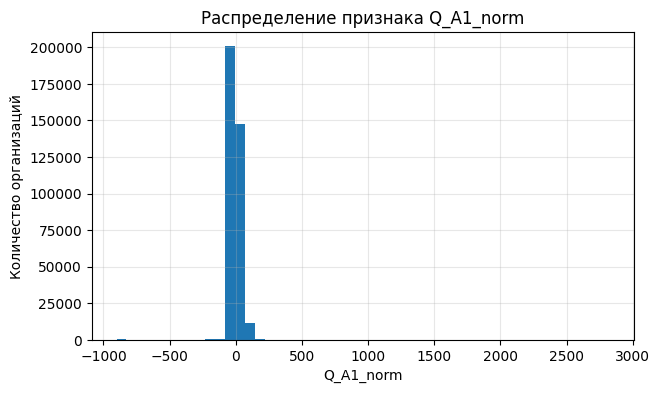

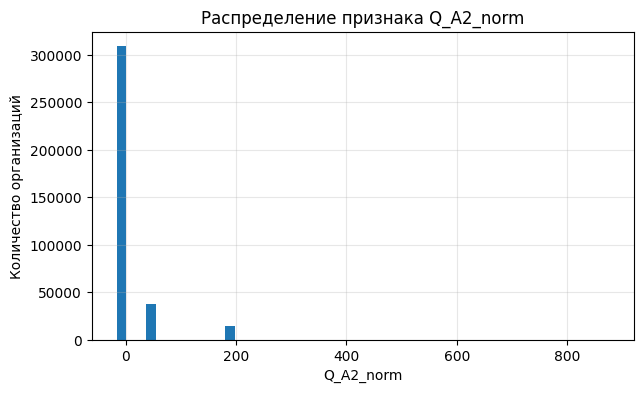

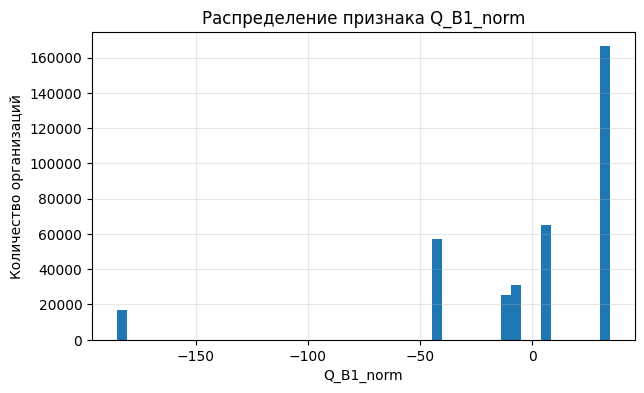

In [ ]:
# Построение гистограмм распределения выбранных признаков

for col in columns:

    plt.figure(figsize=(7,4))

    plt.hist(df[col], bins=50)

    plt.title(f"Распределение признака {col}")
    plt.xlabel(col)
    plt.ylabel("Количество организаций")

    plt.grid(alpha=0.3)

    plt.show()

## 📊 Результаты

Для выбранных признаков были построены гистограммы распределения значений.

Анализ показал, что признаки имеют различную форму распределения. Для некоторых из них характерна высокая концентрация наблюдений в отдельных диапазонах, тогда как другие содержат широкий разброс значений и отдельные экстремальные наблюдения.

## 🔎 Интерпретация

Полученные результаты подтверждают, что признаки существенно отличаются по своим свойствам. Такие различия могут влиять на работу алгоритмов машинного обучения и на информативность отдельных признаков при прогнозировании дефолта.

Кроме того, визуальный анализ помогает обнаружить особенности данных, которые не всегда можно заметить только по описательной статистике.

## 📝 Выводы

Гистограммы позволили получить более полное представление о структуре данных и подтвердили, что признаки имеют неоднородные распределения. Следующим этапом станет сравнение распределений признаков для организаций с дефолтом и без него, чтобы оценить их способность разделять классы.

# 7. Сравнение распределений признаков в зависимости от факта дефолта

## 🎯 Цель

Определить, отличаются ли распределения выбранных признаков у компаний с дефолтом и без дефолта. Это позволит предварительно оценить, насколько информативны признаки для построения модели кредитного скоринга.

## 📌 Почему этот этап выполняется сейчас?

На предыдущих этапах мы изучили структуру датасета, проверили качество данных и рассмотрели распределения отдельных признаков. Теперь необходимо понять, связаны ли эти признаки с целевой переменной. Это следующий логичный этап исследования перед обучением моделей машинного обучения.

## 🛠️ Решение

Для каждого выбранного признака построим наложенные гистограммы отдельно для компаний

без дефолта (`DefMark = 0`)

и компаний с дефолтом (`DefMark = 1`).

Такой подход позволяет визуально сравнить распределения двух групп и оценить, насколько хорошо признак потенциально разделяет классы.

## 📈 Что ожидаем увидеть?

Если распределения заметно отличаются, это означает, что признак может содержать полезную информацию для прогнозирования дефолта. Если распределения практически совпадают, то сам по себе данный признак, вероятно, обладает невысокой разделяющей способностью.

## ✅ Почему выбран именно этот метод?

Для сравнения распределений выбраны наложенные гистограммы. В отличие от boxplot, который в основном показывает медиану, квартили и выбросы, гистограммы позволяют увидеть форму распределения каждого класса и степень их перекрытия. Для задач бинарной классификации такой способ визуализации является более информативным и легче интерпретируется при анализе признаков.

## P.S.

Для сравнения распределений использовались разные типы визуализации. Для непрерывных признаков применялись графики оценки плотности (KDE), позволяющие наглядно сравнить форму распределений двух классов. Для признаков с небольшим количеством дискретных значений использовались гистограммы, поскольку сглаживание KDE в таких случаях может создавать ложное представление о распределении данных.

In [ ]:
import seaborn as sns

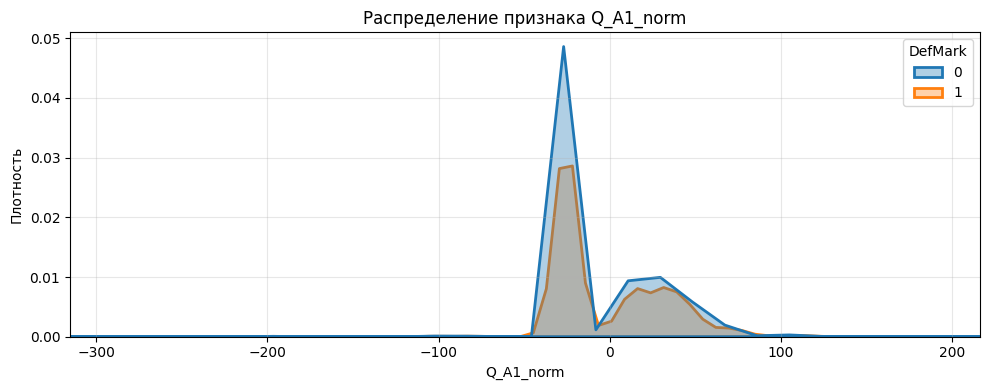

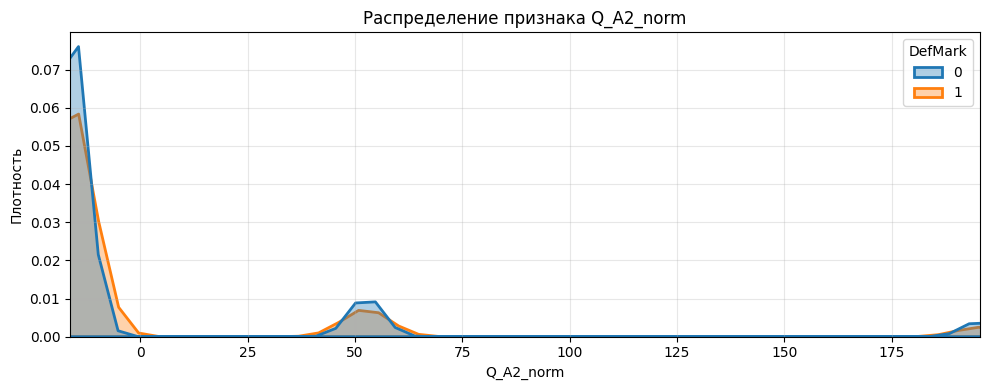

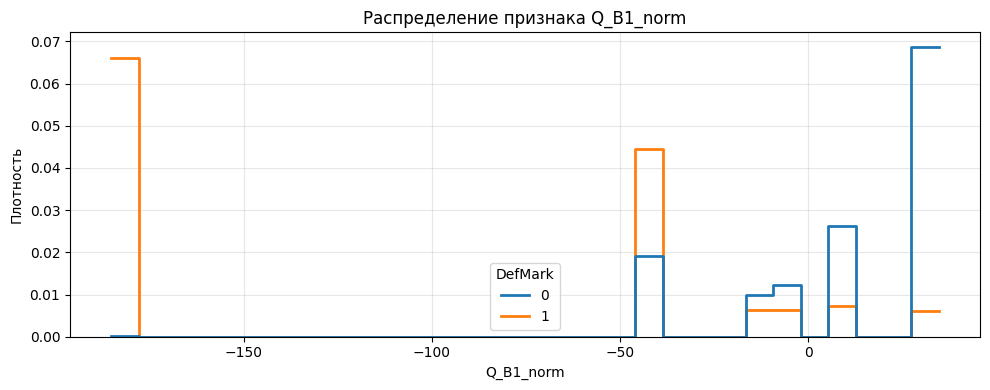

In [ ]:
# @title
# ==========================================================
# Сравнение распределений признаков по целевой переменной
# ==========================================================

# Признаки, для которых будем использовать KDE
kde_features = [
    "Q_A1_norm",
    "Q_A2_norm"
]

# ----------------------------------------------------------
# 1. Анализ непрерывных признаков с помощью KDE
# ----------------------------------------------------------

for feature in kde_features:

    # Создаем новое окно графика
    plt.figure(figsize=(10, 4))

    # Строим оценки плотности для двух классов
    sns.kdeplot(
        data=df,
        x=feature,
        hue="DefMark",
        fill=True,
        common_norm=False,
        alpha=0.35,
        linewidth=2
    )
    '''
    Для повышения читаемости графиков при визуализации непрерывных признаков
    диапазон оси X был ограничен 99,9%-м квантилем.
    Это позволило исключить влияние единичных экстремальных значений
    на масштаб графиков без изменения самих данных.
    '''
    left = df[feature].quantile(0.001)
    right = df[feature].quantile(0.999)

    plt.xlim(left, right)

    # Заголовок и подписи осей
    plt.title(f"Распределение признака {feature}")
    plt.xlabel(feature)
    plt.ylabel("Плотность")

    # Добавляем сетку
    plt.grid(alpha=0.3)

    # Аккуратно размещаем элементы
    plt.tight_layout()

    # Показываем график
    plt.show()


# ----------------------------------------------------------
# 2. Анализ дискретного признака с помощью гистограммы
# ----------------------------------------------------------

plt.figure(figsize=(10, 4))

sns.histplot(
    data=df,
    x="Q_B1_norm",
    hue="DefMark",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2
)

plt.title("Распределение признака Q_B1_norm")
plt.xlabel("Q_B1_norm")
plt.ylabel("Плотность")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Интерпретация полученных графиков

Для каждого признака были отдельно построены распределения компаний с дефолтом (`DefMark = 1`) и без дефолта (`DefMark = 0`).

При анализе графиков оценивались следующие характеристики:

- степень перекрытия распределений двух классов;
- наличие смещения распределений относительно друг друга;
- различия в форме распределений.

Если распределения практически совпадают, это свидетельствует о том, что признак сам по себе слабо различает компании с дефолтом и без дефолта. Если же распределения заметно отличаются, такой признак потенциально может быть информативным при построении модели кредитного скоринга.

Следует учитывать, что данный анализ носит предварительный характер. Окончательная оценка информативности признаков будет выполнена после обучения моделей машинного обучения с использованием соответствующих метрик качества и анализа важности признаков.

## 📝 Выводы

Сравнение распределений признаков показало, что не все исследуемые переменные обладают одинаковой разделяющей способностью.

Для признаков **Q_A1_norm** и **Q_A2_norm** распределения компаний с дефолтом и без дефолта практически совпадают. Это позволяет предположить, что по отдельности данные признаки содержат ограниченную информацию для разделения классов.

В то же время признак **Q_B1_norm** демонстрирует более заметные различия между двумя группами компаний. Распределения отличаются как по форме, так и по расположению основных значений, что указывает на потенциальную информативность данного признака при решении задачи кредитного скоринга.

Следует отметить, что визуальный анализ позволяет лишь предварительно оценить возможную полезность признаков. Окончательные выводы об их влиянии могут быть сделаны только после обучения моделей машинного обучения и анализа их качества.

# 8. Анализ корреляции признаков

## 🎯 Цель

Оценить взаимосвязи между числовыми признаками и выявить наличие сильной корреляции, которая может привести к избыточности информации при построении модели.

## 📌 Почему этот этап выполняется сейчас?

На предыдущем этапе были исследованы распределения признаков и их связь с целевой переменной. Однако даже информативные признаки могут содержать дублирующую информацию.

Если два признака сильно коррелируют между собой, они могут описывать одно и то же свойство объекта. Анализ корреляции позволяет выявить такие зависимости и лучше понять структуру данных перед построением моделей машинного обучения.

## 🛠️ Решение

Для оценки линейной взаимосвязи между признаками используется коэффициент корреляции Пирсона.

Значения коэффициента находятся в диапазоне от **−1** до **1**:

- **1** — идеальная положительная линейная зависимость;
- **−1** — идеальная отрицательная линейная зависимость;
- **0** — линейная зависимость отсутствует.

Результаты удобно представить в виде тепловой карты (Heatmap), где интенсивность цвета отражает силу корреляции между признаками.

## 📈 Что ожидаем увидеть?

После построения корреляционной матрицы мы сможем:

- определить пары сильно коррелирующих признаков;
- оценить наличие мультиколлинеарности;
- понять, потребуется ли исключение или преобразование некоторых признаков на следующих этапах анализа.

## ✅ Почему выбран именно этот метод?

Корреляционная матрица является одним из наиболее распространённых инструментов первичного анализа признаков. Она позволяет быстро обнаружить линейные зависимости между переменными и принять обоснованные решения при подготовке данных к обучению модели.

In [ ]:
# @title
corr = df.corr(numeric_only=True)

corr

,INN,DefMark,Q_A1_norm,Q_A2_norm,Q_A3_norm,Q_A4_norm,Q_A5_norm,Q_A6_norm,Q_A7_norm,Q_B1_norm,...,E3_norm,F1_norm,F2_norm,F3_norm,F4_norm,G1_norm,G2_norm,G3_norm,G4_norm,G5_norm
INN,1.000000,0.009349,-0.395440,0.028733,0.005776,0.019668,-0.059177,-0.019495,-0.014935,-0.043173,...,0.034821,-0.007204,-0.020314,0.023266,0.006762,0.016958,0.018230,0.003625,0.002912,0.009449
DefMark,0.009349,1.000000,-0.026959,-0.012270,-0.017610,-0.077839,-0.248698,-0.066392,-0.030495,-0.672817,...,-0.040472,-0.122838,-0.058269,-0.081907,0.066924,-0.085399,-0.059691,-0.068818,-0.064591,0.030875
Q_A1_norm,-0.395440,-0.026959,1.000000,0.006367,-0.004035,-0.006730,0.037474,0.000330,0.023511,0.045656,...,-0.021917,0.010577,0.018624,-0.012324,-0.005509,-0.009648,-0.004594,0.003008,0.001526,-0.009246
Q_A2_norm,0.028733,-0.012270,0.006367,1.000000,0.025704,-0.026397,-0.010191,-0.011104,-0.015395,0.017826,...,0.014889,0.004890,-0.005057,0.014975,-0.006355,0.203578,0.156642,0.058829,0.048642,-0.078345
Q_A3_norm,0.005776,-0.017610,-0.004035,0.025704,1.000000,-0.029253,-0.027135,-0.103021,-0.027134,0.000994,...,-0.003499,0.009248,-0.035941,0.010865,-0.028935,0.039452,0.039654,0.013561,0.004412,-0.017588
Q_A4_norm,0.019668,-0.077839,-0.006730,-0.026397,-0.029253,1.000000,0.032781,-0.052119,0.161686,0.042041,...,0.070266,0.006077,0.007732,0.033881,0.000912,-0.045788,-0.026992,-0.021789,-0.019552,0.038525
Q_A5_norm,-0.059177,-0.248698,0.037474,-0.010191,-0.027135,0.032781,1.000000,0.329208,0.018102,0.384288,...,0.064664,0.167262,0.125374,0.121441,-0.095997,0.084877,0.062202,0.075153,0.072598,-0.047325
Q_A6_norm,-0.019495,-0.066392,0.000330,-0.011104,-0.103021,-0.052119,0.329208,1.000000,-0.046571,0.207215,...,0.030989,0.169710,0.199785,0.037839,-0.057647,0.096979,0.079659,0.084623,0.082663,-0.056448
Q_A7_norm,-0.014935,-0.030495,0.023511,-0.015395,-0.027134,0.161686,0.018102,-0.046571,1.000000,0.020855,...,0.036061,-0.003929,-0.009580,0.035209,-0.001716,-0.055730,-0.035632,-0.018954,-0.018297,0.048212
Q_B1_norm,-0.043173,-0.672817,0.045656,0.017826,0.000994,0.042041,0.384288,0.207215,0.020855,1.000000,...,0.050277,0.202547,0.100057,0.127058,-0.118549,0.105655,0.088259,0.106260,0.097802,-0.013931


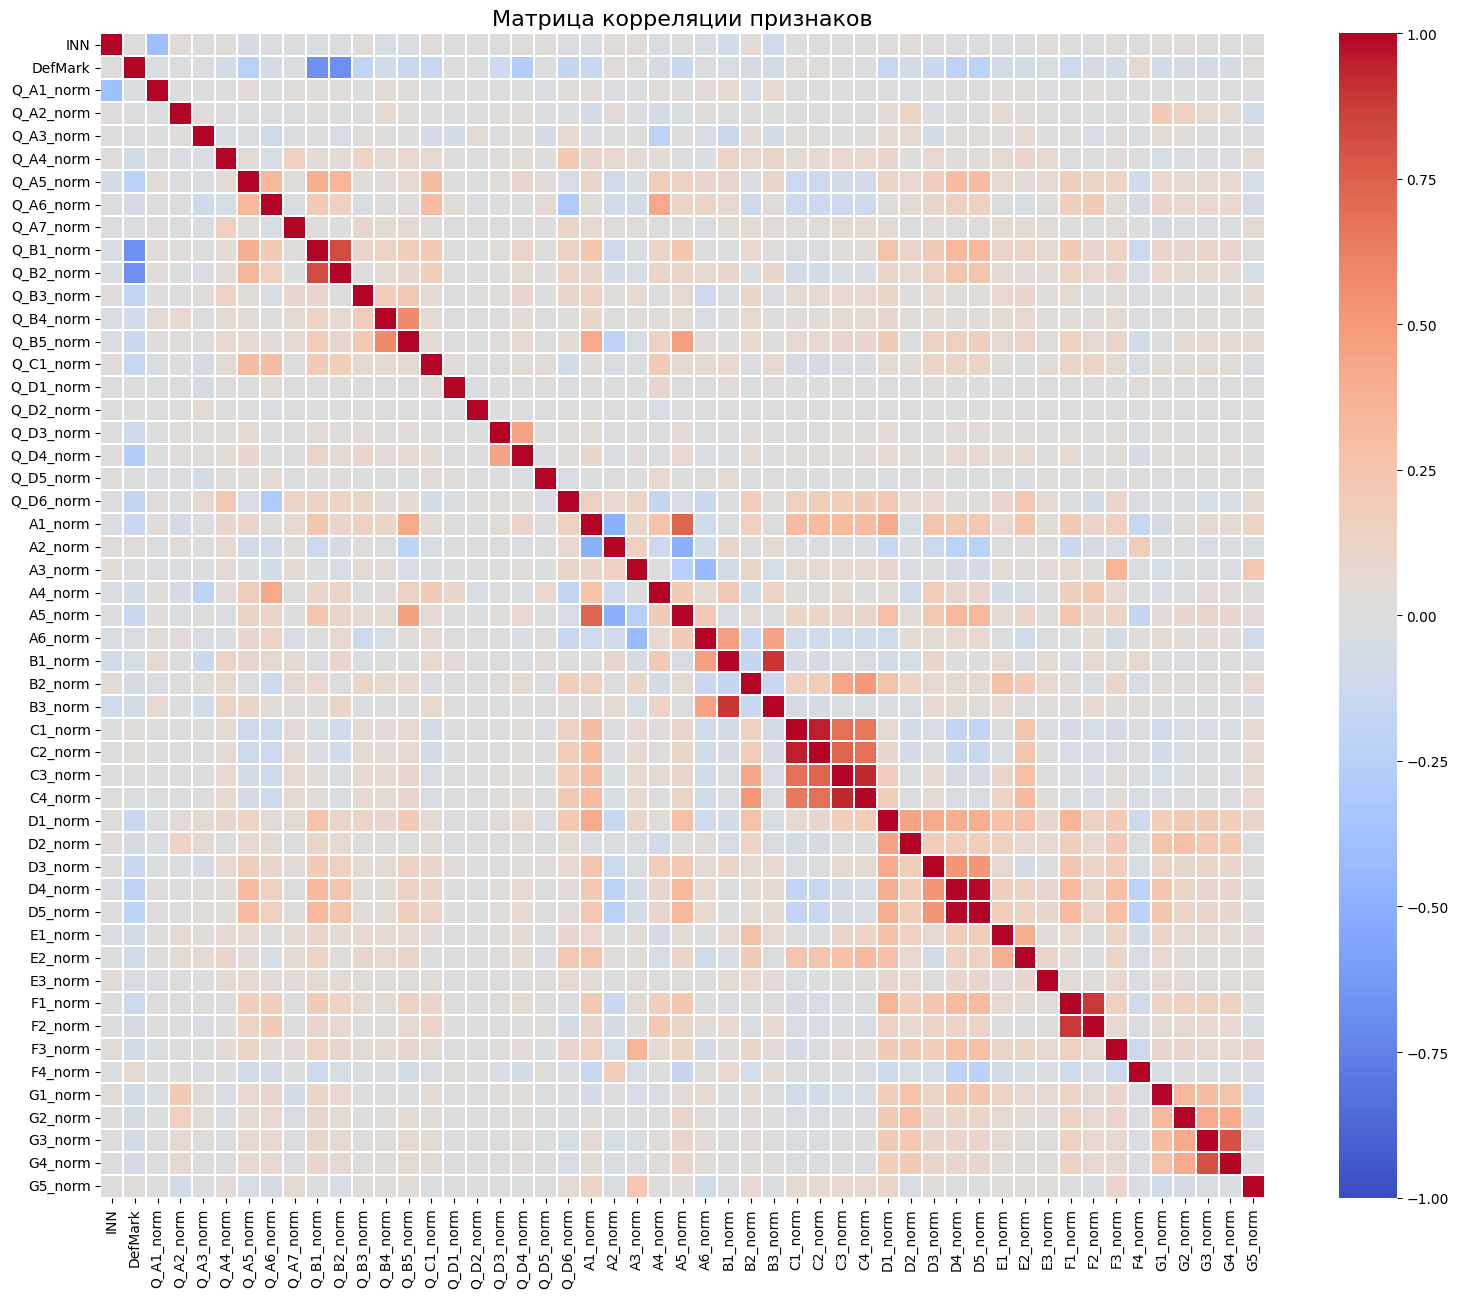

In [ ]:
# @title
plt.figure(figsize=(16, 13))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    annot=False          # убрать цифры
)

plt.title("Матрица корреляции признаков", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Интерпретация результатов

Построенная матрица корреляции позволила оценить линейные взаимосвязи между числовыми признаками.

Большинство коэффициентов корреляции имеют небольшие значения, что свидетельствует об отсутствии сильной линейной зависимости между основной частью признаков. Это говорит о том, что большинство переменных описывают различные характеристики объектов и не являются полными дубликатами друг друга.

Вместе с тем были выявлены отдельные группы признаков с умеренной и высокой корреляцией. Такие зависимости ожидаемы, поскольку некоторые финансовые показатели рассчитываются на основе одних и тех же исходных данных и поэтому могут изменяться согласованно.

В целом анализ не выявил большого количества сильно коррелирующих признаков, что свидетельствует об отсутствии выраженной мультиколлинеарности в исследуемом наборе данных.

## 📝 Выводы

Корреляционный анализ позволил получить общее представление о взаимосвязях между признаками и убедиться, что большинство из них не дублируют друг друга.

Выявленные пары с высокой корреляцией требуют внимания на этапе построения моделей, однако сами по себе не являются основанием для удаления признаков. Решение о необходимости их исключения должно приниматься с учетом особенностей используемого алгоритма машинного обучения и результатов оценки качества модели.

Полученные результаты подтверждают, что данные подготовлены для перехода к следующему этапу исследования — построению и обучению моделей кредитного скоринга.

# 9. Итоговое заключение

## Итоги исследования

В ходе работы был проведён первичный анализ датасета, предназначенного для решения задачи кредитного скоринга.

В рамках исследования были изучены структура набора данных, типы признаков, качество данных, распределения переменных, баланс целевой переменной, а также взаимосвязи между признаками и их связь с фактом дефолта.

Проведённый анализ показал, что предоставленный датасет обладает хорошим качеством и подходит для последующего применения методов машинного обучения. Существенных проблем, способных препятствовать построению моделей, выявлено не было.

Анализ распределений показал, что отдельные признаки демонстрируют различную степень разделения компаний с дефолтом и без него, что свидетельствует о потенциальной информативности части признаков. При этом корреляционный анализ не выявил выраженной мультиколлинеарности, которая могла бы существенно осложнить дальнейшее моделирование.

Таким образом, поставленная цель исследования была достигнута. Полученные результаты позволяют сделать вывод, что датасет подготовлен для дальнейшего этапа работы — построения и сравнительного анализа моделей машинного обучения.